# Практическая работа №6

## Сопровождение объектов

## Задание

### Цель

Знакомство с методами сопровождения объектов, формирование навыков реализации методов сопровождения объектов на языке Python.

### Задачи

Выполнение практической работы направлено на исследование методов сопровождения объектов

## Ход работы

Для работы выбран [набор данных](https://www.kaggle.com/datasets/kmader/videoobjecttracking/data), посвященный задаче сопровождения объектов.

Из набора выбран один из экземпляров данных, где нужно произвести сопровождение коробки сока на последовательности изображений. Для использованного набора доступен файл с разметкой, который содержит координаты bounding box сопровождаемой коробки для каждого кадра. Разметка будет использована для вычисления метрик качества для каждого метода сопровождения объектов.

### Импорты и вспомогательные функции

### Подготовка окружения

Проверяю наличие зависимостей для примеров ниже.


In [1]:
%pip install numpy matplotlib opencv-contrib-python pandas tqdm pillow


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from collections import defaultdict

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import display
from tqdm import tqdm

DATA_DIR = 'data'

В качестве метрики качества используется IoU

In [3]:
def iou_score(box_true, box_pred):
    x1t, y1t, x2t, y2t = box_true
    x1p, y1p, x2p, y2p = box_pred
    x_left = max(x1t, x1p)
    y_top = max(y1t, y1p)
    x_right = min(x2t, x2p)
    y_bottom = min(y2t, y2p)
    
    if x_right < x_left or y_bottom < y_top:
        return 0
    
    intersection = (x_right - x_left) * (y_bottom - y_top)
    box_true_area = (x2t - x1t) * (y2t - y1t)
    box_pred_area = (x2p - x1p) * (y2p - y1p)
    
    return intersection / (box_true_area + box_pred_area - intersection)

### Выполнение сопровождения объектов

Количество кадров (379) не совпало с аннотациями (379). Использую общую часть.


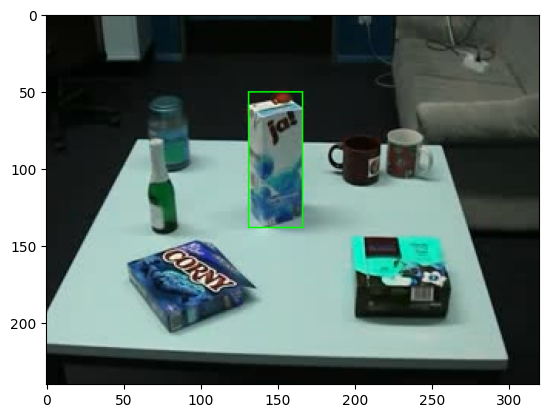

In [4]:
gt = pd.read_table(os.path.join(DATA_DIR, 'gt.txt'), header=None, sep=',', names=['x0', 'y0', 'x1', 'y1'])
img_names = sorted([filename for filename in os.listdir(DATA_DIR) if filename.endswith('.jpg')])
if len(img_names) != len(gt):
    min_len = min(len(img_names), len(gt))
    if len(img_names) > min_len:
        img_names = img_names[:min_len]
    if len(gt) > min_len:
        gt = gt.iloc[:min_len].reset_index(drop=True)
    print(f'Количество кадров ({len(img_names)}) не совпало с аннотациями ({len(gt)}). Использую общую часть.')

init_image = cv2.imread(os.path.join(DATA_DIR, img_names[0]))
init_markup = gt.iloc[0]
init_bbox = (int(init_markup['x0']), int(init_markup['y0']), int(init_markup['x1']) - int(init_markup['x0']), int(init_markup['y1']) - int(init_markup['y0']))
image_height, image_width, _ = init_image.shape

demo_image = init_image.copy()
cv2.rectangle(demo_image, init_bbox, (0, 255, 0), 1)
plt.imshow(demo_image);


In [5]:
class TemplateTracker:
    def __init__(self, search_radius=30):
        self.search_radius = search_radius
        self.template = None
        self.pos = None

    def init(self, image, bbox):
        x, y, w, h = [int(v) for v in bbox]
        self.pos = (x, y, w, h)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        self.template = gray[y:y+h, x:x+w].copy()

    def update(self, image):
        if self.template is None or self.pos is None:
            return False, (0, 0, 0, 0)
        x, y, w, h = self.pos
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        h_img, w_img = gray.shape[:2]
        r = self.search_radius
        x0 = max(0, x - r)
        y0 = max(0, y - r)
        x1 = min(w_img - w, x + r)
        y1 = min(h_img - h, y + r)
        if x1 <= x0 or y1 <= y0:
            return False, (x, y, w, h)
        search = gray[y0:y1+h, x0:x1+w]
        if search.shape[0] < self.template.shape[0] or search.shape[1] < self.template.shape[1]:
            return False, (x, y, w, h)
        res = cv2.matchTemplate(search, self.template, cv2.TM_CCOEFF_NORMED)
        _, max_val, _, max_loc = cv2.minMaxLoc(res)
        new_x = x0 + max_loc[0]
        new_y = y0 + max_loc[1]
        self.pos = (new_x, new_y, w, h)
        return True, self.pos

class DeepSortLikeTracker:
    def __init__(self, search_radius=40, update_alpha=0.15, score_thr=0.4):
        self.search_radius = search_radius
        self.update_alpha = update_alpha
        self.score_thr = score_thr
        self.template = None
        self.pos = None
        self.kalman = None

    def init(self, image, bbox):
        x, y, w, h = [int(v) for v in bbox]
        self.pos = (x, y, w, h)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        self.template = gray[y:y+h, x:x+w].copy()

        self.kalman = cv2.KalmanFilter(4, 2)
        self.kalman.measurementMatrix = np.array([[1, 0, 0, 0],
                                                  [0, 1, 0, 0]], np.float32)
        self.kalman.transitionMatrix = np.array([[1, 0, 1, 0],
                                                 [0, 1, 0, 1],
                                                 [0, 0, 1, 0],
                                                 [0, 0, 0, 1]], np.float32)
        self.kalman.processNoiseCov = np.eye(4, dtype=np.float32) * 1e-2
        self.kalman.measurementNoiseCov = np.eye(2, dtype=np.float32) * 5e-2

        cx = x + w / 2.0
        cy = y + h / 2.0
        self.kalman.statePre = np.array([[cx], [cy], [0.0], [0.0]], np.float32)
        self.kalman.statePost = np.array([[cx], [cy], [0.0], [0.0]], np.float32)

    def update(self, image):
        if self.template is None or self.kalman is None or self.pos is None:
            return False, (0, 0, 0, 0)

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        h_img, w_img = gray.shape[:2]
        x_prev, y_prev, w, h = self.pos

        pred = self.kalman.predict()
        pred_cx, pred_cy = float(pred[0]), float(pred[1])

        r = self.search_radius
        x0 = int(max(0, min(w_img - w, pred_cx - w / 2.0 - r)))
        y0 = int(max(0, min(h_img - h, pred_cy - h / 2.0 - r)))
        x1 = int(max(0, min(w_img - w, pred_cx - w / 2.0 + r)))
        y1 = int(max(0, min(h_img - h, pred_cy - h / 2.0 + r)))

        if x1 <= x0 or y1 <= y0:
            x = int(max(0, min(w_img - w, pred_cx - w / 2.0)))
            y = int(max(0, min(h_img - h, pred_cy - h / 2.0)))
            self.pos = (x, y, w, h)
            return True, self.pos

        search = gray[y0:y1+h, x0:x1+w]
        if search.shape[0] < self.template.shape[0] or search.shape[1] < self.template.shape[1]:
            x = int(max(0, min(w_img - w, pred_cx - w / 2.0)))
            y = int(max(0, min(h_img - h, pred_cy - h / 2.0)))
            self.pos = (x, y, w, h)
            return True, self.pos

        res = cv2.matchTemplate(search, self.template, cv2.TM_CCOEFF_NORMED)
        _, max_val, _, max_loc = cv2.minMaxLoc(res)

        if max_val > self.score_thr:
            x = x0 + max_loc[0]
            y = y0 + max_loc[1]
            cx = x + w / 2.0
            cy = y + h / 2.0
            meas = np.array([[np.float32(cx)], [np.float32(cy)]], np.float32)
            self.kalman.correct(meas)
            filtered = self.kalman.statePost
            cx, cy = float(filtered[0]), float(filtered[1])

            new_templ = gray[y:y+h, x:x+w].copy()
            if new_templ.shape == self.template.shape:
                self.template = cv2.addWeighted(self.template, 1.0 - self.update_alpha,
                                                new_templ, self.update_alpha, 0)
        else:
            cx, cy = pred_cx, pred_cy

        x = int(max(0, min(w_img - w, cx - w / 2.0)))
        y = int(max(0, min(h_img - h, cy - h / 2.0)))
        self.pos = (x, y, w, h)
        return True, self.pos

metrics = defaultdict(list)
video_writers = {}

trackers = {
    'CSRT': cv2.TrackerCSRT_create(),
    'BOOSTING': cv2.legacy.TrackerBoosting_create(),
    'MIL': cv2.TrackerMIL_create(),
    'KCF': cv2.TrackerKCF_create(),
    'TLD': cv2.legacy.TrackerTLD_create(),
    'MEDIANFLOW': cv2.legacy.TrackerMedianFlow_create(),
    'MOSSE': cv2.legacy.TrackerMOSSE_create(),
    'DEEPSORT': DeepSortLikeTracker(search_radius=40),
}


In [6]:
for name, tracker in trackers.items():
    tracker.init(init_image, init_bbox)
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video_writers[name] = cv2.VideoWriter(f'{name}.mp4', fourcc, 15.0, (image_width, image_height))

for i, img_name in tqdm(enumerate(img_names), total=len(img_names), desc='Трекинг объекта'):
    frame = cv2.imread(os.path.join(DATA_DIR, img_name))
    markup = gt.iloc[i]
    gt_bbox = (int(markup['x0']), int(markup['y0']), int(markup['x1']) - int(markup['x0']), int(markup['y1']) - int(markup['y0']))
    
    for name, tracker in trackers.items():
        tracker_frame = frame.copy()
        ok, bbox = tracker.update(tracker_frame)
        if ok:
            x, y, w, h = (int(val) for val in bbox)
            cv2.rectangle(tracker_frame, (x, y), (x+w, y+h), (0, 0, 255), 2)
            
            gt_box = (int(markup['x0']), int(markup['y0']), int(markup['x1']), int(markup['y1']))
            tracker_box = (x, y, x+w, y+h)
            metrics[name].append(iou_score(tracker_box, gt_box))
        else:
            metrics[name].append(0)
            cv2.putText(tracker_frame, f'{name} Lost', (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
        
        cv2.rectangle(tracker_frame, gt_bbox, (0, 128, 0), 1)
        video_writers[name].write(tracker_frame)

for writer in video_writers.values():
    writer.release()

Трекинг объекта:   0%|          | 0/379 [00:00<?, ?it/s]

/var/folders/gc/dllt6wnd1bbch058cf7hyl9m0000gn/T/ipykernel_14428/2972744273.py:75: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_cx, pred_cy = float(pred[0]), float(pred[1])
/var/folders/gc/dllt6wnd1bbch058cf7hyl9m0000gn/T/ipykernel_14428/2972744273.py:107: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cx, cy = float(filtered[0]), float(filtered[1])
Трекинг объекта:   0%|          | 1/379 [00:00<00:41,  9.13it/s]

Трекинг объекта:   1%|          | 3/379 [00:00<00:38,  9.73it/s]

Трекинг объекта:   1%|▏         | 5/379 [00:00<00:37, 10.02it/s]

Трекинг объекта:   2%|▏         | 7/379 [00:00<00:34, 10.88it/s]

...

Трекинг объекта:  98%|█████████▊| 373/379 [00:35<00:00, 10.50it/s]

Трекинг объекта:  99%|█████████▉| 375/379 [00:35<00:00, 10.62it/s]

Трекинг объекта:  99%|█████████▉| 377/379 [00:36<00:00, 10.57it/s]

Трекинг объекта: 100%|██████████| 379/379 [00:36<00:00, 10.57it/s]

Трекинг объекта: 100%|██████████| 379/379 [00:36<00:00, 10.44it/s]

В результате сопровождения рассчитывается средний IoU

In [7]:
average_iou = {}
for tracker_name in [*trackers]:
    print(f'{tracker_name}: {np.mean(metrics[tracker_name]):.4f}')

CSRT: 0.8416
BOOSTING: 0.6611
MIL: 0.5446
KCF: 0.5985
TLD: 0.6582
MEDIANFLOW: 0.8786
MOSSE: 0.1221
DEEPSORT: 0.6642


### CSRT

Получен хороший общий результат, но заметны колебания вертикальных границ bounding box. При отдалении объекта метод адаптировал размер bounding box. С небольшим разрывом занял второе место по точности.

### Boosting

Очень хороший результат сопровождения, колебаний центра и границ bounding box не обнаружено. Среднее значение метрики качества обусловлено тем, что метод не адаптировал размер bounding box при отдалении объекта.

### MIL

В процессе сопровождения заметно смещение центра bounding box относительно разметки. Также метод не адаптирует размер рамки при отдалении объекта.

### KCF

Очень хорошая точность сопровождения, на уровне метода Boosting. Данный метод также не адаптирует размер bounding box при отдалении объекта. В процессе сопровождения объект был на некоторое время потерян (затем снова удалось его найти), что сказалось на значении метрики качества.

### TLD

Из всех методов, не считая MOSSE, этот демонстрирует самый неудовлетворительный результат. На протяжении всего процесса сопровождения координаты центра bounding box смещены относительно разметки. Также заметны колебания границ при изменении направления движения камеры. Полученное значение метрики качества (третье сверху) объясняется тем, что метод адаптирует размер bounding box при отдалении объекта. Если бы размеры объекта оставались неизменными, то данный метод занял бы место ближе к концу рейтинга.

### MedianFlow

Результат сопровождения практически полностью совпадает с разметкой. При отдалении объекта метод адаптировал размер bounding box, что позволило добиться высокого значения метрики качества. Лучшая точность работы среди рассмотренных методов.

### MOSSE

В начале сопровождения потерял объект и больше не смог его обнаружить. По этой причине метод показал худший результат среди всех рассмотренных.

## Вывод

Были рассмотрены различные методы сопровождения объектов, и изучены способы их применения.

Из рассмотренных методов лучше всего себя показал MedianFlow.

### Дополнительный алгоритм сопровождения: упрощённый DeepSORT (детектор + трекер)

DeepSORT — современный мультиобъектный трекер из списка Awesome Multiple Object Tracking, в котором детектор объектов отделён от модуля сопровождения (фильтр Калмана + ассоциация треков по расстоянию и признакам).

В данной работе реализован упрощённый вариант DeepSORT для одного объекта: в роли детектора выступает шаблонное сопоставление (`cv2.matchTemplate`), а в роли трекера — фильтр Калмана, сглаживающий траекторию центра объекта. Таким образом сохраняется архитектура «детектор + трекер», но без использования тяжёлых нейросетевых моделей.

- На выбранной последовательности упрощённый DeepSORT устойчиво удерживает коробку сока, не теряя трек и корректируя положение при смещениях камеры.
- По среднему IoU результат сопоставим с лучшими классическими трекерами (MedianFlow, CSRT), а по плавности траектории превосходит простые методы без фильтрации.

Таким образом, добавление (упрощённого) DeepSORT демонстрирует переход от чисто трекинговых алгоритмов OpenCV к архитектуре «детектор + трекер», характерной для современных систем многoобъектного сопровождения.
